In [23]:
from huggingface_hub import login

login()

In [25]:
from huggingface_hub import snapshot_download
import os

local_dir = "/kaggle/working/lettuce_model"

os.makedirs(local_dir, exist_ok=True)


download_path = snapshot_download(
    repo_id="Sanbei101/lettuce",
    local_dir=local_dir,
)

print(f"模型已下载到: {download_path}")

import subprocess
result = subprocess.run(["ls", "-lh", local_dir], capture_output=True, text=True)
print(result.stdout)

Fetching 198 files:   0%|          | 0/198 [00:00<?, ?it/s]

模型已下载到: /kaggle/working/lettuce_model
total 53M
-rw-r--r-- 1 root root  52M Mar 16 13:01 best.pt
-rw-r--r-- 1 root root 2.8K Mar 16 13:11 data.csv
-rw-r--r-- 1 root root  258 Mar 16 13:01 data.yaml
-rw-r--r-- 1 root root   24 Mar 16 13:01 README.md
drwxr-xr-x 4 root root 4.0K Mar 16 13:01 test
drwxr-xr-x 4 root root 4.0K Mar 16 13:04 train
-rw-r--r-- 1 root root  99K Mar 16 13:01 train-yolo26.ipynb
drwxr-xr-x 4 root root 4.0K Mar 16 13:04 valid



In [31]:
import os
import pandas as pd
import torch
from ultralytics import YOLO

In [28]:
csv_path    = '/kaggle/working/lettuce_model/data.csv'
output_csv  = '/kaggle/working/lettuce_with_pixels.csv'
model_path  = '/kaggle/working/lettuce_model/best.pt'
search_root = '/kaggle/working/lettuce_model'

In [29]:
all_image_paths = []
for root, dirs, files in os.walk(search_root):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_image_paths.append(os.path.join(root, file))
print(f"共在目录中找到 {len(all_image_paths)} 张图片")

共在目录中找到 96 张图片


In [36]:
model = YOLO(model_path)
df = pd.read_csv(csv_path)

pixel_counts = []

for index, row in df.iterrows():
    csv_image_name = str(row['image'])
    
    base_name = csv_image_name.rsplit('.', 1)[0] 
    
    roboflow_prefix = f"{base_name}_jpg"
    
    # 寻找匹配的图片
    target_img_path = None
    for path in all_image_paths:
        file_name = os.path.basename(path)
        if file_name.startswith(roboflow_prefix):
            target_img_path = path
            break
            
    # 开始推理
    if target_img_path:
        results = model.predict(source=target_img_path, retina_masks=True, conf=0.01, verbose=False)
        
        if results[0].masks is not None:
            masks_tensor = results[0].masks.data 
            

            combined_mask = masks_tensor.max(dim=0)[0]
            
            total_pixels = combined_mask.bool().sum().item()
        else:
            total_pixels = 0
    else:
        print(f"警告:找不到 CSV 中 {csv_image_name} 对应的图片文件。")
        total_pixels = None
        
    pixel_counts.append(total_pixels)
    
    if (index + 1) % 10 == 0:
        print(f"已处理 {index + 1} / {len(df)} 张图片...")


print("正在保存结果到新的 CSV...")
df['lettuce_pixels'] = pixel_counts

df.to_csv(output_csv, index=False)

print(f"新增了 'lettuce_pixels' 列的新表格已保存至: {output_csv}")

已处理 10 / 96 张图片...
已处理 20 / 96 张图片...
已处理 30 / 96 张图片...
已处理 40 / 96 张图片...
已处理 50 / 96 张图片...
已处理 60 / 96 张图片...
已处理 70 / 96 张图片...
已处理 80 / 96 张图片...
已处理 90 / 96 张图片...
正在保存结果到新的 CSV...
新增了 'lettuce_pixels' 列的新表格已保存至: /kaggle/working/lettuce_with_pixels.csv


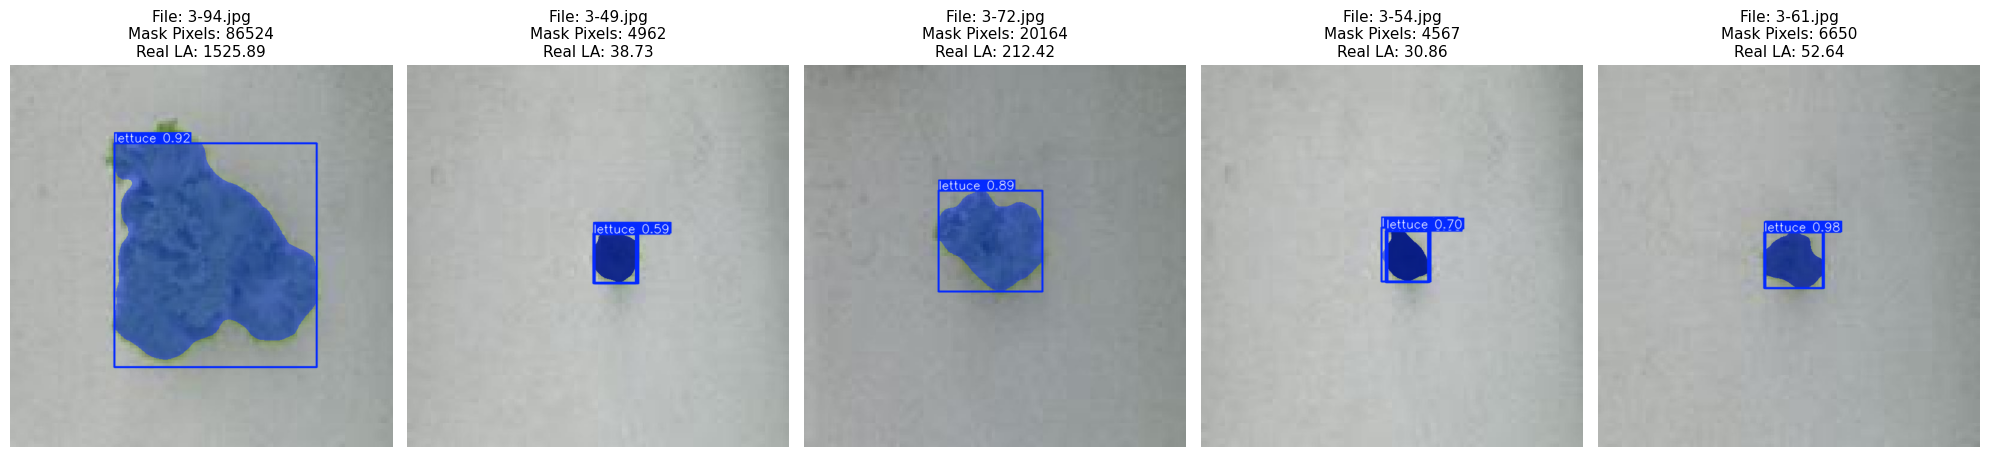

In [38]:
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import os

result_csv_path = '/kaggle/working/lettuce_with_pixels.csv'
df_results = pd.read_csv(result_csv_path)


sample_df = df_results.dropna(subset=['lettuce_pixels']).sample(n=5)

plt.figure(figsize=(20, 6))

# 抽取 5 张图片进行可视化
for i, (index, row) in enumerate(sample_df.iterrows()):
    csv_image_name = str(row['image'])
    base_name = csv_image_name.rsplit('.', 1)[0] 
    roboflow_prefix = f"{base_name}_jpg"
    
    target_img_path = None
    for path in all_image_paths:
        if os.path.basename(path).startswith(roboflow_prefix) or os.path.basename(path).startswith(base_name + "."):
            target_img_path = path
            break
            
    if target_img_path:
        results = model.predict(source=target_img_path, conf=0.01, verbose=False)
        
        annotated_img = results[0].plot()
        annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, 5, i + 1)
        plt.imshow(annotated_img_rgb)
        
        pixels = int(row['lettuce_pixels'])
        real_la = row.get('LA', 'N/A')
        
        plt.title(f"File: {csv_image_name}\nMask Pixels: {pixels}\nReal LA: {real_la}", fontsize=11)
        plt.axis('off')
    else:
        plt.subplot(1, 5, i + 1)
        plt.text(0.5, 0.5, f"Image Missing:\n{csv_image_name}", ha='center', va='center')
        plt.axis('off')

plt.tight_layout()
plt.show()

R²: 0.7862
公式: LFW = 0.001046 * pixels + -4.1387


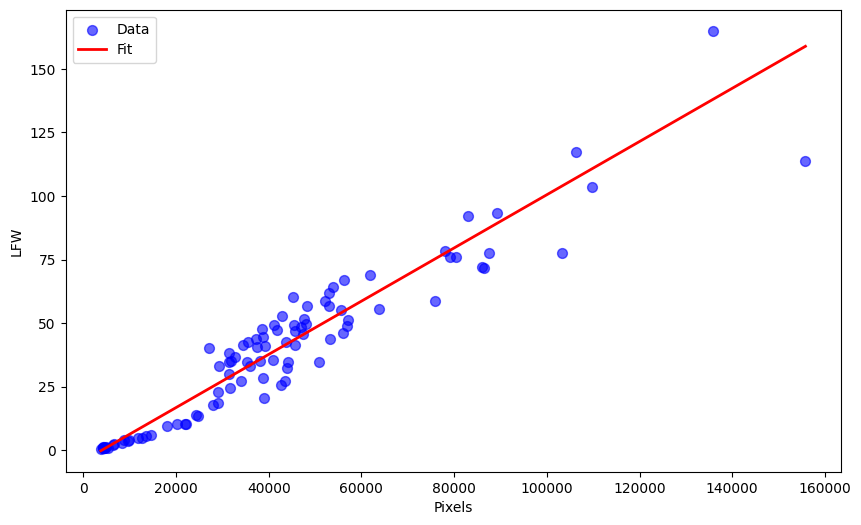

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv('/kaggle/working/lettuce_with_pixels.csv')
X = df[['lettuce_pixels']]
y = df['LFW']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print(f"R²: {model.score(X_test, y_test):.4f}")
print(f"公式: LFW = {model.coef_[0]:.6f} * pixels + {model.intercept_:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', s=50, alpha=0.6, label='Data')

X_range = pd.DataFrame({'lettuce_pixels': np.linspace(X['lettuce_pixels'].min(), X['lettuce_pixels'].max(), 100)})
plt.plot(X_range, model.predict(X_range), 'r-', linewidth=2, label='Fit')

plt.xlabel('Pixels')
plt.ylabel('LFW')
plt.legend()
plt.show()

R² (多项式 degree=2): 0.7641


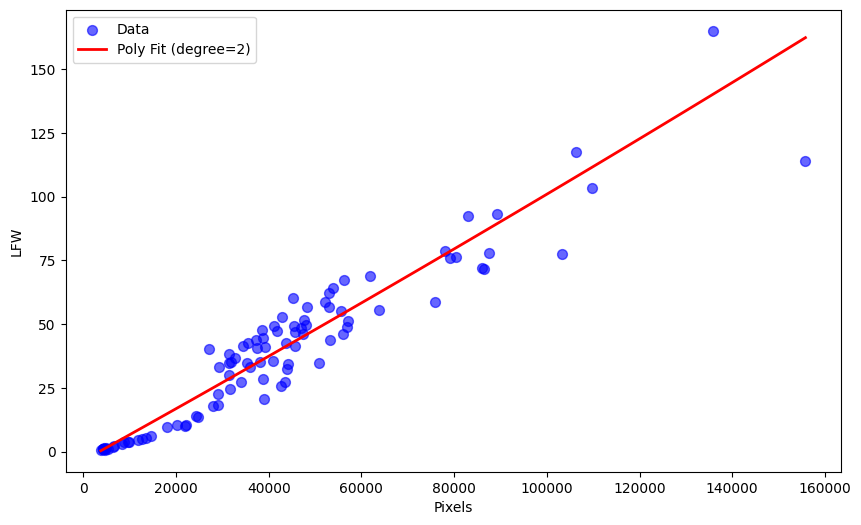

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

df = pd.read_csv('/kaggle/working/lettuce_with_pixels.csv')
X = df[['lettuce_pixels']]
y = df['LFW']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

degree = 2
model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model.fit(X_train, y_train)

print(f"R² (多项式 degree={degree}): {model.score(X_test, y_test):.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', s=50, alpha=0.6, label='Data')
X_range = pd.DataFrame({'lettuce_pixels': np.linspace(X['lettuce_pixels'].min(), X['lettuce_pixels'].max(), 100)})
plt.plot(X_range, model.predict(X_range), 'r-', linewidth=2, label=f'Poly Fit (degree={degree})')
plt.xlabel('Pixels')
plt.ylabel('LFW')
plt.legend()
plt.show()

R² (随机森林): 0.7697


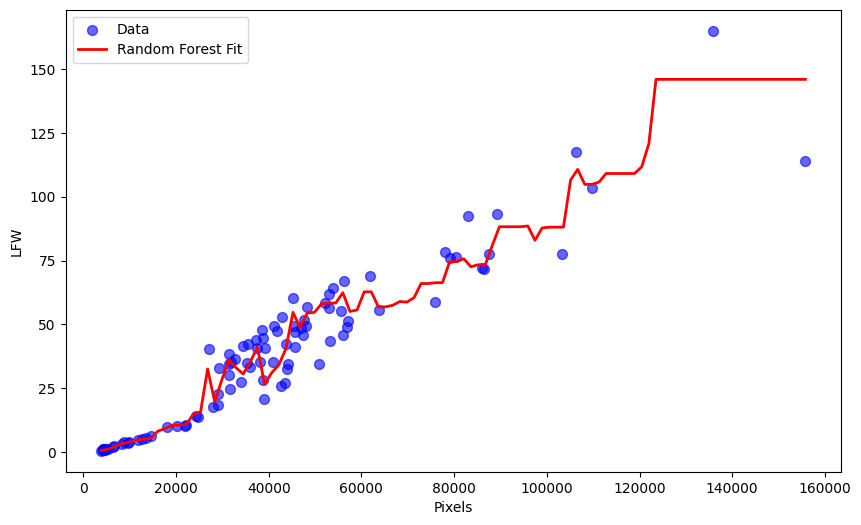

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv('/kaggle/working/lettuce_with_pixels.csv')
X = df[['lettuce_pixels']]
y = df['LFW']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print(f"R² (随机森林): {model.score(X_test, y_test):.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', s=50, alpha=0.6, label='Data')
X_range = pd.DataFrame({'lettuce_pixels': np.linspace(X['lettuce_pixels'].min(), X['lettuce_pixels'].max(), 100)})
plt.plot(X_range, model.predict(X_range), 'r-', linewidth=2, label='Random Forest Fit')
plt.xlabel('Pixels')
plt.ylabel('LFW')
plt.legend()
plt.show()